In [3]:
import pandas as pd
import numpy as np

# โหลดข้อมูลและจัดการคอมม่าในหลักพันด้วย thousands=','
df = pd.read_csv('/Users/hilmanyusoh/Desktop/stock_pattern/data/ข้อมูลย้อนหลังของ ดัชนี SET 100.csv', thousands=',')

# แสดง 5 แถวแรกเพื่อตรวจสอบ
df.head()

,วันเดือนปี,ล่าสุด,ราคาเปิด,สูงสุด,ต่ำสุด,ปริมาณ,% เปลี่ยน
0,03/13/2026,2000.68,2015.93,2023.86,1992.50,2.92B,-1.49%
1,03/12/2026,2030.92,1981.82,2031.01,1979.86,2.99B,1.81%
2,03/11/2026,1994.77,2005.44,2027.22,1994.77,3.28B,0.05%
3,03/10/2026,1993.83,2002.12,2011.29,1974.74,3.24B,1.57%
4,03/09/2026,1962.94,1904.99,1967.94,1887.28,4.25B,-2.02%


In [4]:
# เปลี่ยนชื่อคอลัมน์ให้เป็นภาษาอังกฤษ
column_map = {
    'วันเดือนปี': 'Date',
    'ล่าสุด': 'Close',
    'ราคาเปิด': 'Open',
    'สูงสุด': 'High',
    'ต่ำสุด': 'Low',
    'ปริมาณ': 'Vol_Raw',
    '% เปลี่ยน': 'Pct_Change'
}

df = df.rename(columns=column_map)

# ตรวจสอบประเภทข้อมูล (Dtype) ของแต่ละคอลัมน์
print(df.dtypes)
df.head()

Date           object
Close         float64
Open          float64
High          float64
Low           float64
Vol_Raw        object
Pct_Change     object
dtype: object


,Date,Close,Open,High,Low,Vol_Raw,Pct_Change
0,03/13/2026,2000.68,2015.93,2023.86,1992.50,2.92B,-1.49%
1,03/12/2026,2030.92,1981.82,2031.01,1979.86,2.99B,1.81%
2,03/11/2026,1994.77,2005.44,2027.22,1994.77,3.28B,0.05%
3,03/10/2026,1993.83,2002.12,2011.29,1974.74,3.24B,1.57%
4,03/09/2026,1962.94,1904.99,1967.94,1887.28,4.25B,-2.02%


In [5]:
# แปลงคอลัมน์ Date ให้เป็นรูปแบบ datetime
df['Date'] = pd.to_datetime(df['Date'])

# เรียงข้อมูลจากเก่าไปใหม่ (Oldest to Newest)
df = df.sort_values('Date').reset_index(drop=True)

# ตรวจสอบช่วงเวลาของข้อมูล
print(f"ข้อมูลเริ่มตั้งแต่: {df['Date'].min()}")
print(f"ข้อมูลถึงวันที่: {df['Date'].max()}")

ข้อมูลเริ่มตั้งแต่: 2011-08-16 00:00:00
ข้อมูลถึงวันที่: 2026-03-13 00:00:00


In [6]:
def convert_volume(val):
    if isinstance(val, str):
        val = val.upper()
        if 'B' in val:
            return float(val.replace('B', '')) * 1_000_000_000
        elif 'M' in val:
            return float(val.replace('M', '')) * 1_000_000
        elif 'K' in val:
            return float(val.replace('K', '')) * 1_000
    return float(val)

# แปลง Volume เป็นตัวเลข
df['Volume'] = df['Vol_Raw'].apply(convert_volume)

# จัดการคอลัมน์ % เปลี่ยน (เอาเครื่องหมาย % ออกและแปลงเป็น float)
df['Pct_Change'] = df['Pct_Change'].str.replace('%', '').astype(float) / 100

# ลบคอลัมน์ Vol_Raw เดิมทิ้ง
df = df.drop(columns=['Vol_Raw'])

df.head()

,Date,Close,Open,High,Low,Pct_Change,Volume
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,-0.0098,1900000.0
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,0.0165,2030000.0
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,-0.0030,1960000.0
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,-0.0204,2320000.0
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,-0.0008,1890000.0


In [8]:
# เช็คค่าว่าง (NaN)
print("จำนวนค่าว่างในแต่ละคอลัมน์:")
print(df.isnull().sum())



จำนวนค่าว่างในแต่ละคอลัมน์:
Date          0
Close         0
Open          0
High          0
Low           0
Pct_Change    0
Volume        0
dtype: int64


In [11]:
# สรุปค่าสถิติเบื้องต้น
print("\nสรุปข้อมูลเชิงสถิติ:")
display(df.describe())

# ตรวจสอบความต่อเนื่องของวันที่ (Optional: ดูว่ามีวันหยุดที่ข้อมูลขาดหายไปเยอะไหม)
df['Date_Diff'] = df['Date'].diff().dt.days
print(f"\nระยะห่างระหว่างวันสูงสุด: {df['Date_Diff'].max()} วัน")
df = df.drop(columns=['Date_Diff'])


สรุปข้อมูลเชิงสถิติ:


,Date,Close,Open,High,Low,Pct_Change,Volume
count,3554,3554.000000,3554.000000,3554.000000,3554.000000,3554.000000,3.554000e+03
mean,2018-11-21 07:03:48.925154560,2096.207487,2097.598309,2108.634544,2084.234012,0.000113,2.326156e+09
min,2011-08-16 00:00:00,1284.810000,1297.000000,1315.910000,1266.020000,-0.117600,6.303500e+05
25%,2015-03-26 06:00:00,1911.290000,1911.902500,1922.280000,1898.980000,-0.005100,1.710000e+09
50%,2018-11-14 12:00:00,2127.855000,2130.195000,2142.290000,2115.845000,0.000300,2.160000e+09
75%,2022-07-18 18:00:00,2258.737500,2262.012500,2271.272500,2249.462500,0.005400,2.770000e+09
max,2026-03-13 00:00:00,2677.390000,2691.230000,2711.960000,2674.310000,0.091900,1.685000e+10
std,NaN,256.681024,257.237065,256.251983,257.361594,0.010827,1.095946e+09



ระยะห่างระหว่างวันสูงสุด: 6.0 วัน


In [12]:
# 1. คำนวณ Relative Volume (เทียบกับค่าเฉลี่ย 20 วัน)
df['Vol_MA20'] = df['Volume'].rolling(window=20).mean()
df['Rel_Vol'] = df['Volume'] / df['Vol_MA20']

# 2. คำนวณ Close Position (0 = ปิดต่ำสุด, 1 = ปิดสูงสุดของแท่ง)
df['Close_Pos'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'])
# จัดการกรณี High == Low (ป้องกัน Error Division by Zero)
df['Close_Pos'] = df['Close_Pos'].fillna(0.5)

# 3. คำนวณ Price Spread (ความกว้างของแท่งเทียนเทียบกับราคา)
df['Spread'] = (df['High'] - df['Low']) / df['Close']

df.head()

,Date,Close,Open,High,Low,Pct_Change,Volume,Vol_MA20,Rel_Vol,Close_Pos,Spread
0,2011-08-16,1632.90,1656.45,1657.00,1632.90,-0.0098,1900000.0,NaN,NaN,0.000000,0.014759
1,2011-08-17,1659.84,1647.02,1662.93,1645.03,0.0165,2030000.0,NaN,NaN,0.827374,0.010784
2,2011-08-18,1654.86,1669.88,1676.61,1653.01,-0.0030,1960000.0,NaN,NaN,0.078390,0.014261
3,2011-08-19,1621.09,1627.69,1638.60,1616.06,-0.0204,2320000.0,NaN,NaN,0.223159,0.013904
4,2011-08-22,1619.72,1620.20,1621.13,1592.81,-0.0008,1890000.0,NaN,NaN,0.950212,0.017485


In [13]:
# 1. RSI (Relative Strength Index) - ดูสภาวะ Overbought/Oversold
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['Close'])

# 2. Moving Average Convergence Divergence (MACD)
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# 3. SMA 50 และ 200 เพื่อดูแนวโน้มระยะยาว
df['SMA50'] = df['Close'].rolling(window=50).mean()
df['SMA200'] = df['Close'].rolling(window=200).mean()

df.tail()

,Date,Close,Open,High,Low,Pct_Change,Volume,Vol_MA20,Rel_Vol,Close_Pos,Spread,RSI,EMA12,EMA26,MACD,Signal_Line,SMA50,SMA200
3549,2026-03-09,1962.94,1904.99,1967.94,1887.28,-0.0202,4.250000e+09,4.380000e+09,0.970320,0.938011,0.041091,39.205195,2053.075101,2029.353034,23.722067,51.062733,1937.1252,1773.78935
3550,2026-03-10,1993.83,2002.12,2011.29,1974.74,0.0157,3.240000e+09,4.206000e+09,0.770328,0.522298,0.018332,39.192777,2043.960470,2026.721698,17.238772,44.297941,1940.8144,1775.28160
3551,2026-03-11,1994.77,2005.44,2027.22,1994.77,0.0005,3.280000e+09,4.192000e+09,0.782443,0.000000,0.016268,38.190350,2036.392706,2024.354906,12.037800,37.845913,1944.8022,1776.94630
3552,2026-03-12,2030.92,1981.82,2031.01,1979.86,0.0181,2.990000e+09,4.172500e+09,0.716597,0.998240,0.025186,37.939086,2035.550751,2024.841209,10.709542,32.418638,1949.6510,1778.78110
3553,2026-03-13,2000.68,2015.93,2023.86,1992.50,-0.0149,2.920000e+09,4.105500e+09,0.711241,0.260842,0.015675,37.155982,2030.186020,2023.051490,7.134530,27.361817,1954.0636,1780.53640


In [14]:
# 1. Bollinger Bands - ดูความผันผวนและการบีบตัว (Squeeze) ของ Phase B
df['BB_Mid'] = df['Close'].rolling(window=20).mean()
df['BB_Std'] = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Mid'] + (df['BB_Std'] * 2)
df['BB_Lower'] = df['BB_Mid'] - (df['BB_Std'] * 2)

# 2. Distance from SMA (ราคาห่างจากเส้นค่าเฉลี่ยกี่ %?)
df['Dist_SMA50'] = (df['Close'] - df['SMA50']) / df['SMA50']

# 3. ค้นหาจุดสูงสุด-ต่ำสุดย้อนหลัง (ใช้เป็นแนวรับแนวต้านสมมติใน Phase B)
df['High_20'] = df['High'].rolling(window=20).max()
df['Low_20'] = df['Low'].rolling(window=20).min()
df['Dist_High20'] = (df['High_20'] - df['Close']) / df['Close']

df.tail()

,Date,Close,Open,High,Low,Pct_Change,Volume,Vol_MA20,Rel_Vol,Close_Pos,...,SMA50,SMA200,BB_Mid,BB_Std,BB_Upper,BB_Lower,Dist_SMA50,High_20,Low_20,Dist_High20
3549,2026-03-09,1962.94,1904.99,1967.94,1887.28,-0.0202,4.250000e+09,4.380000e+09,0.970320,0.938011,...,1937.1252,1773.78935,2080.1560,69.356743,2218.869487,1941.442513,0.013326,2209.5,1887.28,0.125608
3550,2026-03-10,1993.83,2002.12,2011.29,1974.74,0.0157,3.240000e+09,4.206000e+09,0.770328,0.522298,...,1940.8144,1775.28160,2079.4060,70.244059,2219.894118,1938.917882,0.027316,2209.5,1887.28,0.108169
3551,2026-03-11,1994.77,2005.44,2027.22,1994.77,0.0005,3.280000e+09,4.192000e+09,0.782443,0.000000,...,1944.8022,1776.94630,2077.8020,71.855115,2221.512229,1934.091771,0.025693,2209.5,1887.28,0.107646
3552,2026-03-12,2030.92,1981.82,2031.01,1979.86,0.0181,2.990000e+09,4.172500e+09,0.716597,0.998240,...,1949.6510,1778.78110,2078.0260,71.693373,2221.412746,1934.639254,0.041684,2209.5,1887.28,0.087931
3553,2026-03-13,2000.68,2015.93,2023.86,1992.50,-0.0149,2.920000e+09,4.105500e+09,0.711241,0.260842,...,1954.0636,1780.53640,2074.3615,73.755013,2221.871526,1926.851474,0.023856,2209.5,1887.28,0.104375


In [15]:
# ลบแถวที่มีค่า NaN จากการคำนวณ Rolling (เช่น SMA200 จะทำให้ 200 แถวแรกเป็น NaN)
df_ml = df.dropna().reset_index(drop=True)

# เลือกเฉพาะคอลัมน์ที่จะใช้เป็น Features สำหรับ ML
features_list = [
    'Close', 'Rel_Vol', 'Close_Pos', 'Spread', 
    'RSI', 'MACD', 'Signal_Line', 
    'Dist_SMA50', 'BB_Upper', 'BB_Lower', 'Dist_High20'
]

print(f"จำนวนข้อมูลทั้งหมดหลัง Clean: {len(df_ml)} แถว")
print(f"Features ที่พร้อมใช้งาน: {features_list}")
df_ml[features_list].head()

จำนวนข้อมูลทั้งหมดหลัง Clean: 3355 แถว
Features ที่พร้อมใช้งาน: ['Close', 'Rel_Vol', 'Close_Pos', 'Spread', 'RSI', 'MACD', 'Signal_Line', 'Dist_SMA50', 'BB_Upper', 'BB_Lower', 'Dist_High20']


,Close,Rel_Vol,Close_Pos,Spread,RSI,MACD,Signal_Line,Dist_SMA50,BB_Upper,BB_Lower,Dist_High20
0,1688.19,0.803796,0.202219,0.019216,34.712074,-32.847749,-29.096080,-0.057204,1826.375113,1636.004887,0.082538
1,1702.25,0.550756,1.000000,0.015133,41.740857,-30.844830,-29.445830,-0.047796,1814.225778,1637.406222,0.072798
2,1753.52,0.956629,1.000000,0.013573,55.855885,-24.834169,-28.523498,-0.018378,1802.922800,1642.920200,0.041431
3,1759.91,0.957533,1.000000,0.015899,58.589748,-19.332207,-26.685240,-0.014063,1801.234290,1643.569710,0.023927
4,1751.57,1.042446,0.400559,0.014296,64.128571,-15.466542,-24.441500,-0.018027,1790.818322,1648.940678,0.023413


In [16]:
# 1. กำหนดระยะเวลามองไปข้างหน้า (Forward Looking Window) เช่น 10 วัน
prediction_days = 10

# 2. คำนวณผลตอบแทนในอนาคต (Future Return)
# shift(-n) คือการดึงราคาในอีก n วันข้างหน้ามาไว้ที่บรรทัดปัจจุบัน
df_ml['Future_Return'] = df_ml['Close'].shift(-prediction_days) / df_ml['Close'] - 1

# 3. สร้าง Label (Target)
# 0 = เฉยๆ (Hold/Wait)
# 1 = สัญญาณซื้อ (Buy) -> ถ้าอนาคต 10 วัน ราคาขึ้นมากกว่า 3%
# 2 = สัญญาณขาย (Sell) -> ถ้าอนาคต 10 วัน ราคาลงมากกว่า 3%

buy_threshold = 0.03
sell_threshold = -0.03

df_ml['Target'] = 0
df_ml.loc[df_ml['Future_Return'] > buy_threshold, 'Target'] = 1
df_ml.loc[df_ml['Future_Return'] < sell_threshold, 'Target'] = 2

# ลบแถวสุดท้าย 10 แถวที่เป็น NaN เพราะไม่มีข้อมูลราคาในอนาคตให้เช็ค
df_ml = df_ml.dropna(subset=['Future_Return']).reset_index(drop=True)

print(df_ml['Target'].value_counts())
df_ml[['Date', 'Close', 'Future_Return', 'Target']].head(10)

Target
0    2399
1     509
2     437
Name: count, dtype: int64


,Date,Close,Future_Return,Target
0,2012-06-07,1688.19,0.035985,1
1,2012-06-08,1702.25,0.021436,0
2,2012-06-11,1753.52,-0.013852,0
3,2012-06-12,1759.91,-0.014006,0
4,2012-06-13,1751.57,0.004544,0
5,2012-06-14,1741.94,0.015035,0
6,2012-06-15,1762.86,0.003591,0
7,2012-06-18,1758.13,0.021989,0
8,2012-06-19,1773.03,0.021742,0
9,2012-06-20,1772.90,0.017440,0


In [17]:
# ปรับปรุง Label 1 (Buy) ให้เป็น "จุดซื้อสไตล์ Wyckoff" 
# คือราคาต้องมีแนวโน้มขึ้น + Vol ต้องเริ่มมา + ปิดสวย (Close_Pos > 0.6)

condition_buy = (df_ml['Target'] == 1) & (df_ml['Rel_Vol'] > 1.1) & (df_ml['Close_Pos'] > 0.6)
df_ml['Wyckoff_Label'] = 0
df_ml.loc[condition_buy, 'Wyckoff_Label'] = 1

# ทำเช่นเดียวกันกับฝั่ง Sell (Distribution)
condition_sell = (df_ml['Target'] == 2) & (df_ml['Rel_Vol'] > 1.1) & (df_ml['Close_Pos'] < 0.4)
df_ml.loc[condition_sell, 'Wyckoff_Label'] = 2

print("สรุปจำนวน Label หลังจากกรองด้วย Wyckoff Logic:")
print(df_ml['Wyckoff_Label'].value_counts())

สรุปจำนวน Label หลังจากกรองด้วย Wyckoff Logic:
Wyckoff_Label
0    3227
1      65
2      53
Name: count, dtype: int64


In [18]:
# เลือก Features ที่เราสร้างไว้ใน Step 2
features = [
    'Rel_Vol', 'Close_Pos', 'Spread', 'RSI', 'MACD', 
    'Signal_Line', 'Dist_SMA50', 'BB_Upper', 'BB_Lower', 'Dist_High20'
]

X = df_ml[features]
y = df_ml['Wyckoff_Label']

# ตรวจสอบความพร้อมของข้อมูล
print(f"ขนาดของ Feature Matrix (X): {X.shape}")
print(f"ขนาดของ Target Vector (y): {y.shape}")

ขนาดของ Feature Matrix (X): (3345, 10)
ขนาดของ Target Vector (y): (3345,)


In [19]:
from sklearn.model_selection import train_test_split

# เลือก Features ที่เราเตรียมไว้
X = df_ml[features]
y = df_ml['Wyckoff_Label']

# แบ่งข้อมูล: 80% สำหรับสอน (Train), 20% สำหรับทดสอบ (Test)
# สำคัญ: ต้อง set shuffle=False เพราะข้อมูลหุ้นเป็น Time Series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"จำนวนข้อมูลสำหรับสอน: {len(X_train)} วัน")
print(f"จำนวนข้อมูลสำหรับทดสอบ: {len(X_test)} วัน")

จำนวนข้อมูลสำหรับสอน: 2676 วัน
จำนวนข้อมูลสำหรับทดสอบ: 669 วัน


In [20]:
from xgboost import XGBClassifier

# สร้างโมเดล XGBoost
# learning_rate: ความเร็วในการเรียนรู้
# n_estimators: จำนวนต้นไม้ตัดสินใจ (Decision Trees)
# max_depth: ความลึกของต้นไม้ (ป้องกัน Overfitting)
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='multi:softprob' # สำหรับทายหลาย Class (0, 1, 2)
)

# ฝึกโมเดลด้วยข้อมูล Train
model.fit(X_train, y_train)

print("ฝึกโมเดลเสร็จเรียบร้อยแล้ว!")

ฝึกโมเดลเสร็จเรียบร้อยแล้ว!


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       641
           1       0.25      0.19      0.21        16
           2       0.00      0.00      0.00        12

    accuracy                           0.95       669
   macro avg       0.40      0.39      0.40       669
weighted avg       0.93      0.95      0.94       669



/Users/hilmanyusoh/Desktop/stock_pattern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hilmanyusoh/Desktop/stock_pattern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hilmanyusoh/Desktop/stock_pattern/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

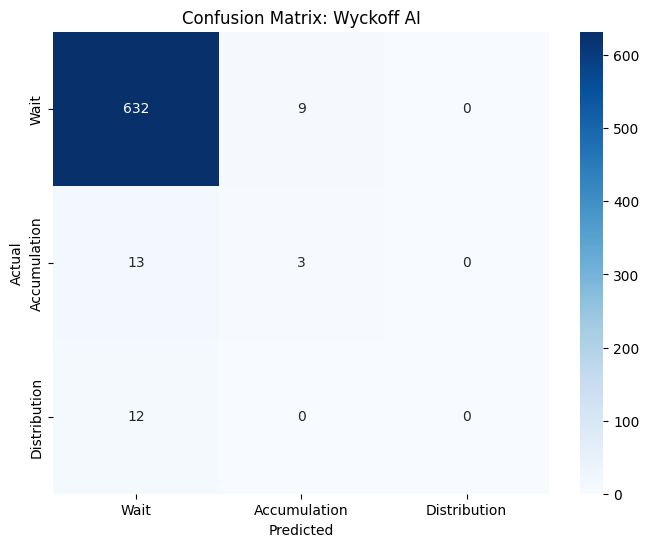

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ให้โมเดลลองทายข้อมูล Test
y_pred = model.predict(X_test)

# แสดงผลความแม่นยำ
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# แสดง Confusion Matrix เพื่อดูว่าทายผิดในจุดไหน
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Wait', 'Accumulation', 'Distribution'],
            yticklabels=['Wait', 'Accumulation', 'Distribution'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Wyckoff AI')
plt.show()

/var/folders/by/j89gc0qj6_zfzkf42sg0dr1c0000gp/T/ipykernel_49298/697365827.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


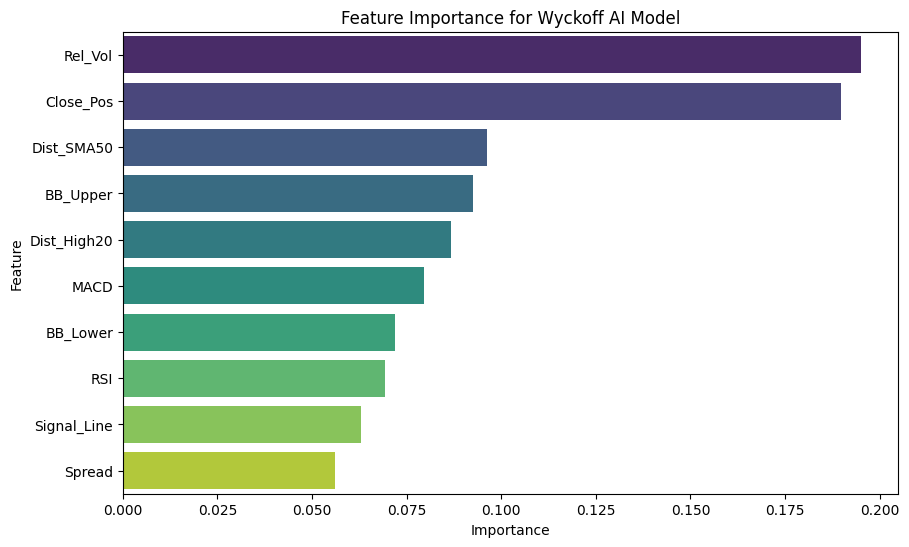

In [22]:
# ดึงค่าความสำคัญของตัวแปร
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# พล็อตกราฟ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance for Wyckoff AI Model')
plt.show()

In [23]:
# ใช้โมเดลพยากรณ์ความน่าจะเป็น (Probability) แทนที่จะเป็นแค่ 0, 1, 2
# เพื่อให้เราเห็นว่า AI มั่นใจในสัญญาณนั้นๆ แค่ไหน
y_prob = model.predict_proba(X_test)

# สร้าง DataFrame สำหรับเก็บผลลัพธ์การทดสอบ
results = df_ml.loc[X_test.index].copy()
results['AI_Prob_Wait'] = y_prob[:, 0]
results['AI_Prob_Buy'] = y_prob[:, 1]
results['AI_Prob_Sell'] = y_prob[:, 2]

# กำหนดเกณฑ์ความมั่นใจ (Confidence Threshold) เช่น ต้องมั่นใจมากกว่า 60% ถึงจะออกคำสั่ง
confidence_threshold = 0.6
results['Signal'] = 0
results.loc[results['AI_Prob_Buy'] > confidence_threshold, 'Signal'] = 1
results.loc[results['AI_Prob_Sell'] > confidence_threshold, 'Signal'] = 2

results[['Date', 'Close', 'AI_Prob_Buy', 'AI_Prob_Sell', 'Signal']].tail(10)

,Date,Close,AI_Prob_Buy,AI_Prob_Sell,Signal
3335,2026-02-13,2059.83,0.006481,0.049709,0
3336,2026-02-16,2068.66,0.001795,0.001978,0
3337,2026-02-17,2099.65,0.380047,0.018049,0
3338,2026-02-18,2108.53,0.172821,0.009823,0
3339,2026-02-19,2146.63,0.138596,0.013193,0
3340,2026-02-20,2126.50,0.009212,0.444999,0
3341,2026-02-23,2121.19,0.007763,0.474852,0
3342,2026-02-24,2138.81,0.002005,0.001806,0
3343,2026-02-25,2172.74,0.010764,0.011328,0
3344,2026-02-26,2194.96,0.002005,0.001806,0


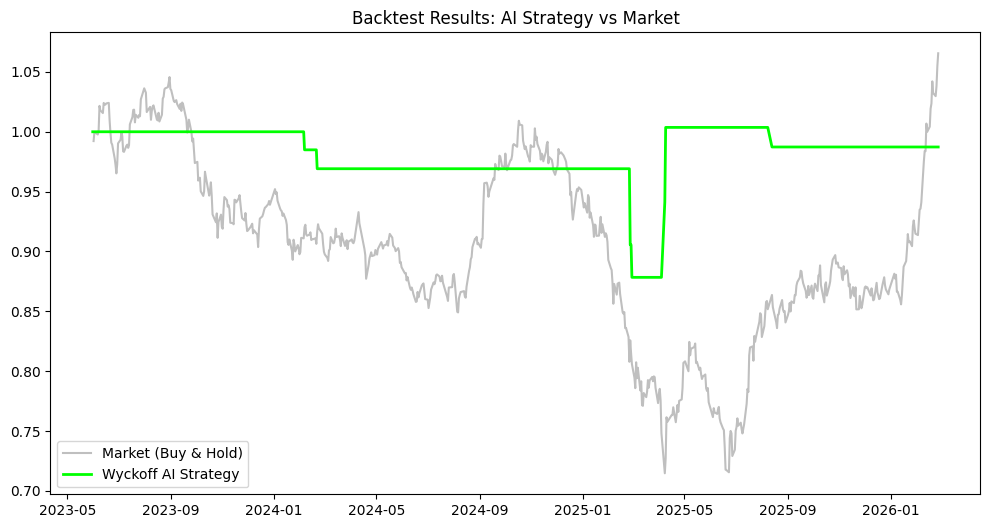

In [24]:
# คำนวณ Strategy Return
# ถ้า Signal เป็น 1 ให้ได้ผลตอบแทนตาม Future_Return ที่คำนวณไว้
results['Strategy_Return'] = 0.0
results.loc[results['Signal'] == 1, 'Strategy_Return'] = results['Future_Return']

# คำนวณผลตอบแทนสะสม (Cumulative Return)
results['Cum_Market_Return'] = (1 + results['Close'].pct_change()).cumprod()
results['Cum_Strategy_Return'] = (1 + results['Strategy_Return']).cumprod()

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(12, 6))
plt.plot(results['Date'], results['Cum_Market_Return'], label='Market (Buy & Hold)', color='gray', alpha=0.5)
plt.plot(results['Date'], results['Cum_Strategy_Return'], label='Wyckoff AI Strategy', color='lime', linewidth=2)
plt.title('Backtest Results: AI Strategy vs Market')
plt.legend()
plt.show()

In [25]:
# กรองเฉพาะวันที่มีสัญญาณซื้อหรือขาย
latest_signals = results[results['Signal'] != 0].tail(10)

print("=== Latest Wyckoff AI Trading Signals ===")
if not latest_signals.empty:
    display(latest_signals[['Date', 'Close', 'Rel_Vol', 'Close_Pos', 'AI_Prob_Buy', 'AI_Prob_Sell', 'Signal']])
else:
    print("ยังไม่พบสัญญาณที่มั่นใจสูงในช่วงนี้")

=== Latest Wyckoff AI Trading Signals ===


,Date,Close,Rel_Vol,Close_Pos,AI_Prob_Buy,AI_Prob_Sell,Signal
2845,2024-02-06,1895.61,1.173347,0.717497,0.749146,0.004803,1
2856,2024-02-21,1887.73,1.389892,0.929137,0.669885,0.009707,1
3102,2025-02-26,1700.89,1.384497,0.887623,0.635139,0.012063,1
3104,2025-02-28,1659.98,1.499632,0.842041,0.689148,0.010701,1
3130,2025-04-08,1472.04,1.723419,0.806175,0.777740,0.009116,1
3131,2025-04-09,1497.66,1.449143,0.797847,0.637384,0.008317,1
3210,2025-08-13,1778.98,1.278143,0.795862,0.609081,0.010275,1
